In [68]:
import yfinance as yf

from datetime import datetime
end = datetime.now()
start = datetime(end.year-20, end.month, end.day)

In [69]:
stock = "GOOG"
google_data = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [70]:
google_data.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2006-08-30,9.400325,9.496612,9.345022,9.362303,162382376
2006-08-31,9.345516,9.434891,9.337369,9.418596,118839777
2006-09-01,9.347244,9.413410,9.312433,9.406251,107316747
2006-09-05,9.489451,9.515128,9.318604,9.378597,163582859
2006-09-06,9.385263,9.460564,9.373412,9.433653,149522354


In [71]:
google_data.shape

(5030, 5)

In [72]:
google_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
count,5029.000000,5029.000000,5029.000000,5029.000000,5.030000e+03
mean,69.239405,69.969694,68.460950,69.192427,7.642003e+07
std,76.120976,76.987643,75.152654,76.033078,8.546475e+07
min,6.355927,6.650467,6.105581,6.481100,1.584340e+05
25%,15.006696,15.131128,14.854362,15.009658,2.422600e+07
50%,38.077785,38.324359,37.697632,38.101077,3.792495e+07
75%,102.194969,103.309152,101.015877,102.099810,9.749306e+07
max,398.799988,404.226718,393.433246,396.821177,9.349835e+08


In [73]:
google_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5030 entries, 2006-08-30 to 2026-08-28
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GOOG)   5029 non-null   float64
 1   (High, GOOG)    5029 non-null   float64
 2   (Low, GOOG)     5029 non-null   float64
 3   (Open, GOOG)    5029 non-null   float64
 4   (Volume, GOOG)  5030 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 235.8 KB


In [74]:
google_data.isnull().sum()

Price   Ticker
Close   GOOG      1
High    GOOG      1
Low     GOOG      1
Open    GOOG      1
Volume  GOOG      0
dtype: int64

In [75]:
google_data.ffill(inplace=True)

# google_data.reset_index()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2006-08-30,9.400325,9.496612,9.345022,9.362303,162382376
2006-08-31,9.345516,9.434891,9.337369,9.418596,118839777
2006-09-01,9.347244,9.413410,9.312433,9.406251,107316747
2006-09-05,9.489451,9.515128,9.318604,9.378597,163582859
2006-09-06,9.385263,9.460564,9.373412,9.433653,149522354
...,...,...,...,...,...
2026-08-24,344.589996,348.079987,339.619995,340.739990,16450600
2026-08-25,343.339996,346.700012,342.144989,345.970001,14031000


In [76]:
google_data.isnull().sum()

Price   Ticker
Close   GOOG      0
High    GOOG      0
Low     GOOG      0
Open    GOOG      0
Volume  GOOG      0
dtype: int64

In [77]:
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'Closing price of Google data')

<Figure size 1500x500 with 0 Axes>

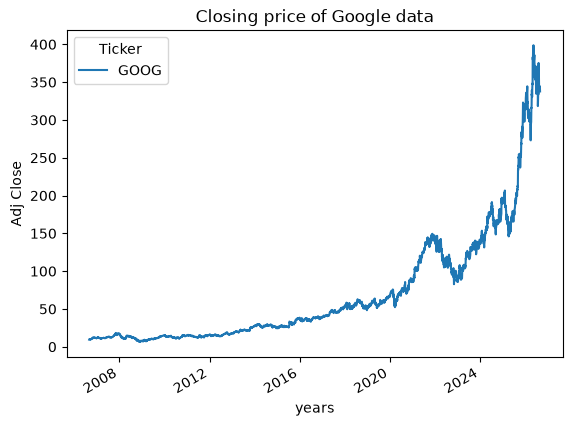

In [78]:
plt.figure(figsize = (15,5))
google_data['Close'].plot()
plt.xlabel("years")
plt.ylabel("Adj Close")
plt.title("Closing price of Google data")

In [79]:
def plot_graph(figsize, values, column_name):
    plt.figure()   # create a blank figure for your graph
    values.plot(figsize = figsize)    # values → the data you want to plot
    plt.xlabel("years")
    plt.ylabel(column_name)
    plt.title(f"{column_name} of Google data")

In [80]:
google_data.columns

MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])

In [81]:
google_data.columns = google_data.columns.droplevel('Ticker')

In [82]:
google_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [83]:
google_data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2006-08-30,9.400325,9.496612,9.345022,9.362303,162382376
2006-08-31,9.345516,9.434891,9.337369,9.418596,118839777
2006-09-01,9.347244,9.413410,9.312433,9.406251,107316747
2006-09-05,9.489451,9.515128,9.318604,9.378597,163582859
2006-09-06,9.385263,9.460564,9.373412,9.433653,149522354


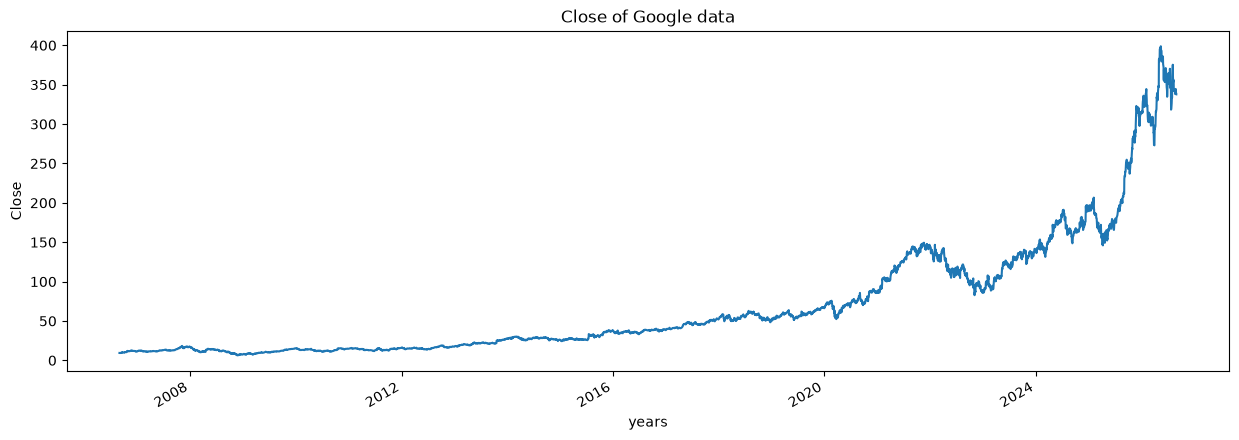

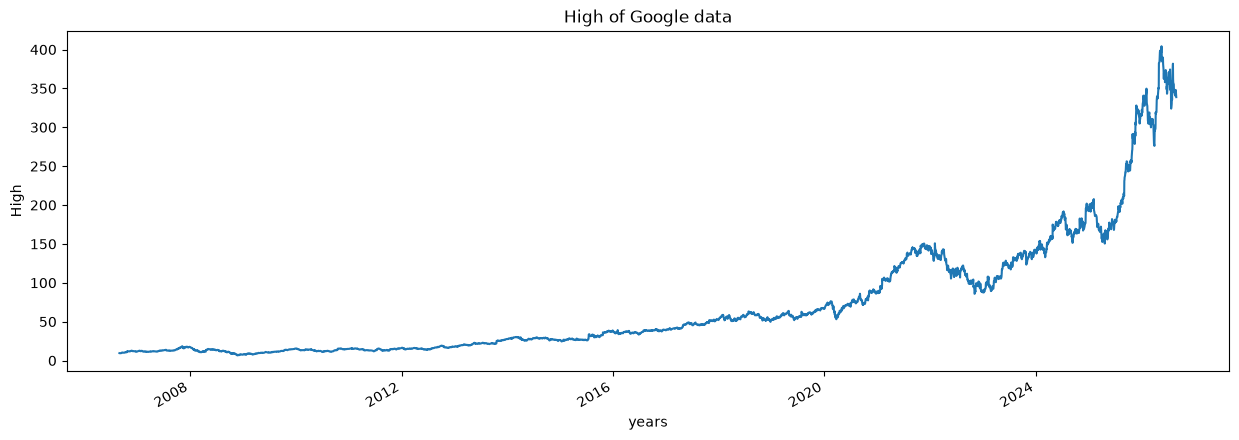

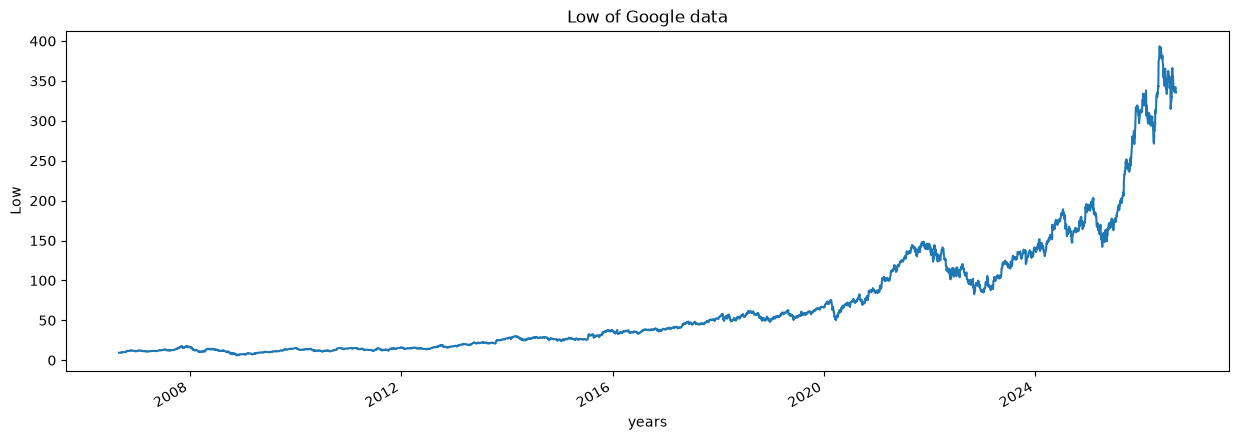

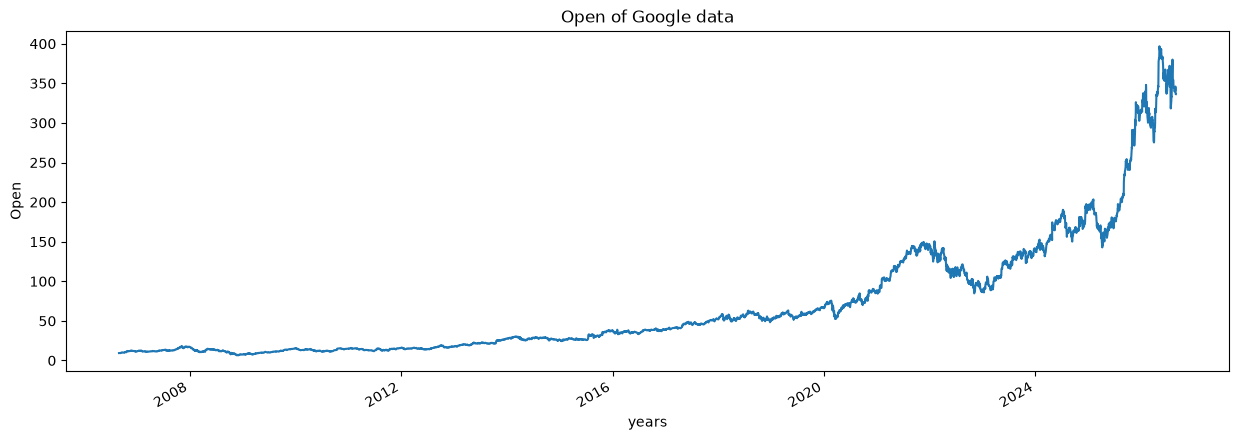

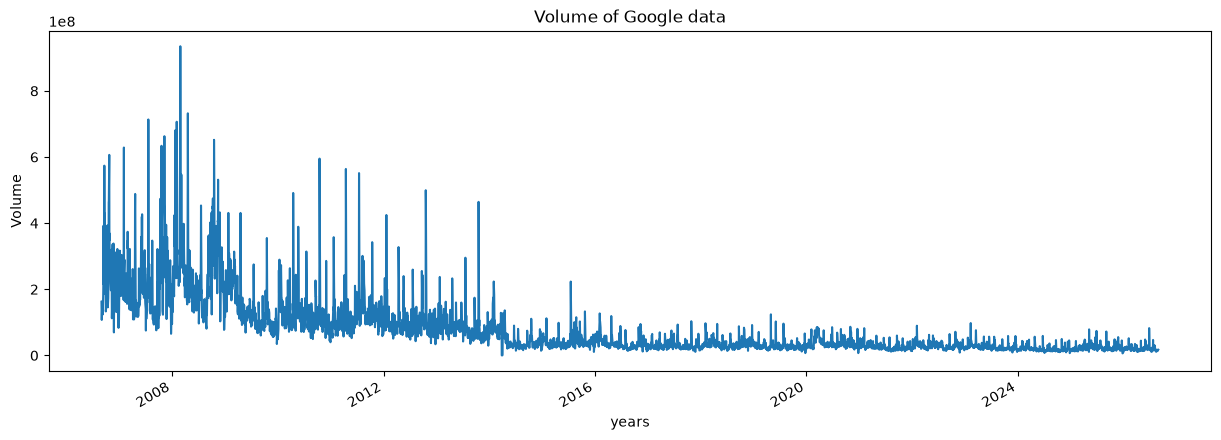

In [84]:
for column in google_data.columns:
    plot_graph((15,5), google_data[column], column)

# google_data[column]  >>>>here is the value 

In [85]:
# 10, 20, 30, 40, 50, 60, 70, 80, 90, 100

# MA for 5 days ==> null null null null 30 40 50 60 70 80

In [86]:
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_data[1:6])/5)

40.0


In [87]:
import pandas as pd
data = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
data.head()

,0
0,10
1,20
2,30
3,40
4,50


In [88]:
data['MA'] = data.rolling(5).mean()
data

,0,MA
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


In [95]:
for i in range(2005, 2026):
    print(i, list(google_data.index.year).count(i))

2005 0
2006 85
2007 251
2008 253
2009 252
2010 252
2011 252
2012 250
2013 252
2014 252
2015 252
2016 252
2017 251
2018 251
2019 252
2020 253
2021 252
2022 251
2023 250
2024 252
2025 250


In [109]:
google_data['MA_for_250_days'] = google_data['Close'].rolling(250).mean()

In [110]:
google_data['MA_for_250_days']

Date
2006-08-30           NaN
2006-08-31           NaN
2006-09-01           NaN
2006-09-05           NaN
2006-09-06           NaN
                 ...    
2026-08-24    315.085989
2026-08-25    315.629918
2026-08-26    316.155849
2026-08-27    316.659628
2026-08-28    317.158780
Name: MA_for_250_days, Length: 5030, dtype: float64

In [114]:
google_data['MA_for_250_days'][0:250].tail()

Date
2007-08-22          NaN
2007-08-23          NaN
2007-08-24          NaN
2007-08-27          NaN
2007-08-28    11.727616
Name: MA_for_250_days, dtype: float64

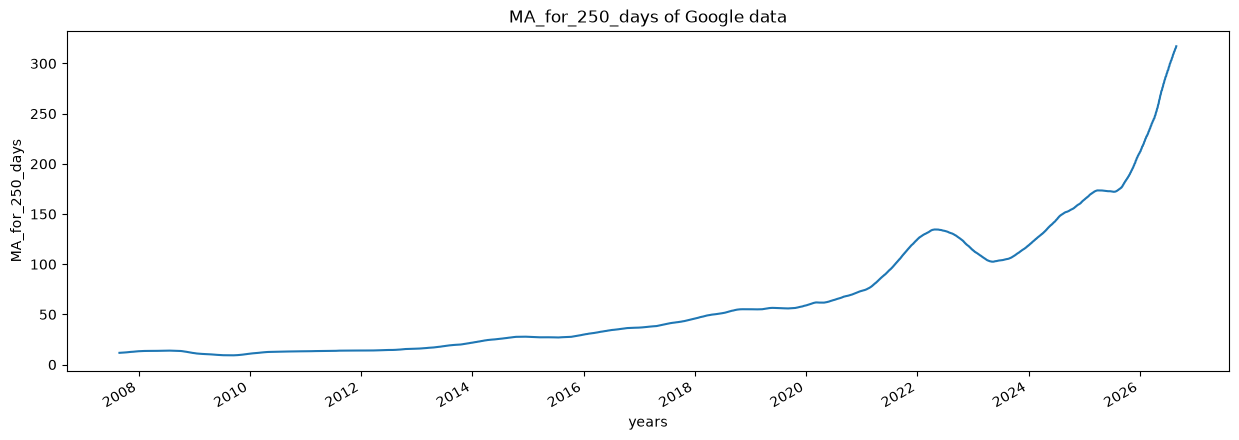

In [102]:
plot_graph((15,5), google_data['MA_for_250_days'], 'MA_for_250_days')

<Figure size 640x480 with 0 Axes>

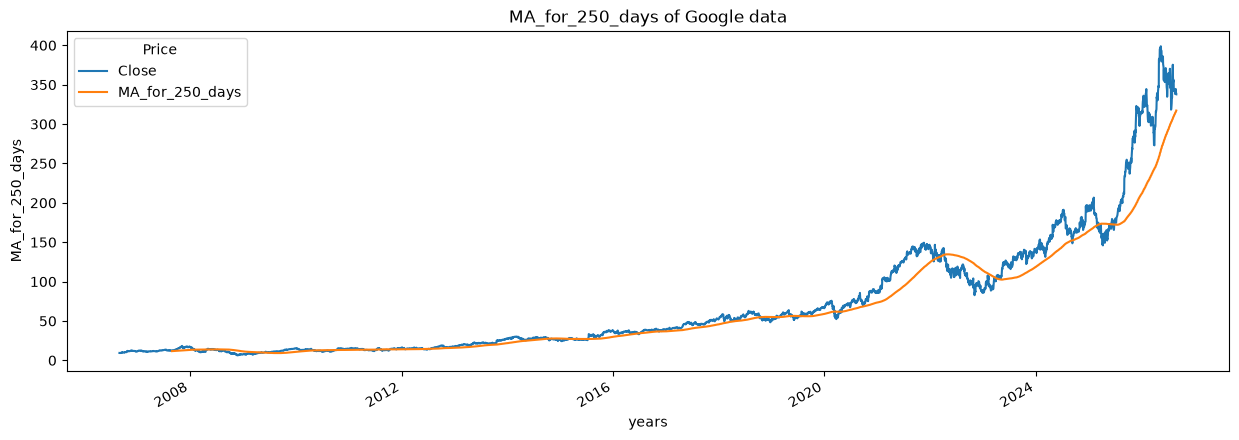

In [104]:
plot_graph((15,5), google_data[['Close','MA_for_250_days']], 'MA_for_250_days')

<Figure size 640x480 with 0 Axes>

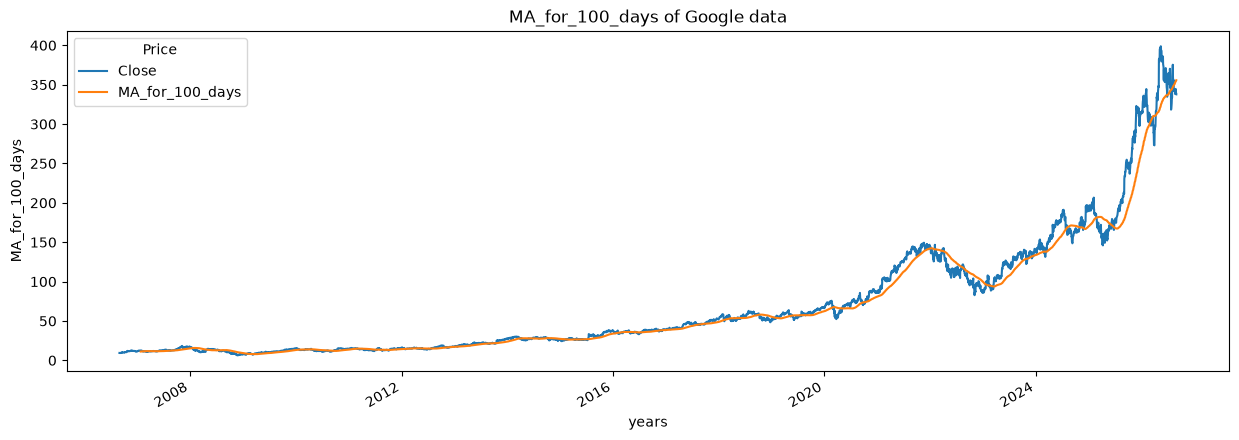

In [105]:
google_data['MA_for_100_days'] = google_data['Close'].rolling(100).mean()
plot_graph((15,5), google_data[['Close','MA_for_100_days']], 'MA_for_100_days')

<Figure size 640x480 with 0 Axes>

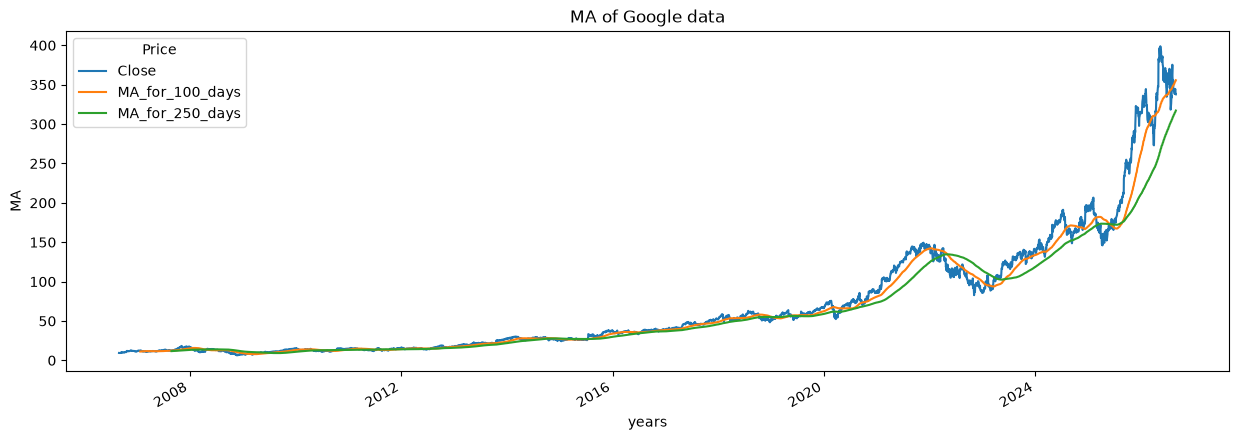

In [106]:
plot_graph((15,5), google_data[['Close','MA_for_100_days', 'MA_for_250_days']], 'MA')

In [107]:
google_data['percentage_change_cp'] = google_data['Close'].pct_change()
google_data[['Close','percentage_change_cp']].head()

Price,Close,percentage_change_cp
Date,,
2006-08-30,9.400325,NaN
2006-08-31,9.345516,-0.005831
2006-09-01,9.347244,0.000185
2006-09-05,9.489451,0.015214
2006-09-06,9.385263,-0.010979


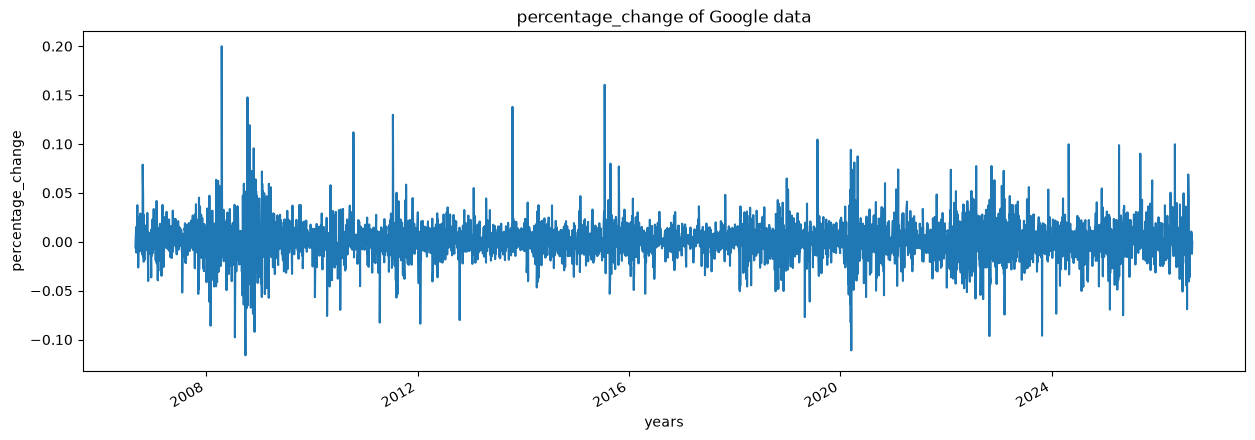

In [108]:
plot_graph((15,5), google_data['percentage_change_cp'], 'percentage_change')

In [116]:
Adj_close_price = google_data[['Close']]

In [117]:
max(Adj_close_price.values),min(Adj_close_price.values)

(array([398.79998779]), array([6.35592699]))

In [150]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(Adj_close_price)
scaled_data

array([[0.00775753],
       [0.00761787],
       [0.00762228],
       ...,
       [0.84787646],
       [0.84433451],
       [0.84433451]], shape=(5030, 1))

In [151]:
len(scaled_data)

5030

In [155]:
x_data = []
y_data = []

for i in range(100, len(scaled_data)):
    x_data.append(scaled_data[i-100:i])
    y_data.append(scaled_data[i])

import numpy as np
x_data, y_data = np.array(x_data), np.array(y_data)

In [156]:
x_data[0],y_data[0]

(array([[0.00775753],
        [0.00761787],
        [0.00762228],
        [0.00798464],
        [0.00771915],
        [0.00761535],
        [0.00757509],
        [0.00796766],
        [0.00845899],
        [0.00938189],
        [0.00921895],
        [0.00959013],
        [0.00989272],
        [0.00920826],
        [0.00877983],
        [0.0093995 ],
        [0.00920637],
        [0.00921895],
        [0.00940077],
        [0.00915226],
        [0.00919379],
        [0.00908809],
        [0.00905915],
        [0.00922272],
        [0.00995626],
        [0.00971155],
        [0.01025824],
        [0.01079298],
        [0.01064514],
        [0.0106357 ],
        [0.01069484],
        [0.01068603],
        [0.01033688],
        [0.01026705],
        [0.01018337],
        [0.01060802],
        [0.01272245],
        [0.0140505 ],
        [0.01358055],
        [0.01441664],
        [0.01432228],
        [0.01369946],
        [0.01378565],
        [0.01377432],
        [0.01321505],
        [0

In [157]:
x_data.shape

(4930, 100, 1)

In [159]:
len(x_data)

4930

In [160]:
int(len(x_data)*0.7)

3451

In [161]:
5030-100-int(len(x_data)*0.7)

1479

In [162]:
splitting_len = int(len(x_data)*0.7)
x_train = x_data[:splitting_len]
y_train = y_data[:splitting_len]

x_test = x_data[splitting_len:]
y_test = y_data[splitting_len:]

In [163]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(3451, 100, 1)
(3451, 1)
(1479, 100, 1)
(1479, 1)


In [164]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [165]:
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(64,return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

C:\Users\USER\anaconda3\envs\stock_price\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [166]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [167]:
model.fit(x_train, y_train, batch_size=1, epochs = 2)

Epoch 1/2
3451/3451 ━━━━━━━━━━━━━━━━━━━━ 183s 51ms/step - loss: 5.3058e-05
Epoch 2/2
3451/3451 ━━━━━━━━━━━━━━━━━━━━ 168s 49ms/step - loss: 2.7536e-05


In [168]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [169]:
predictions = model.predict(x_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step


In [170]:
predictions

array([[0.17144863],
       [0.17279264],
       [0.17584422],
       ...,
       [0.80932844],
       [0.80440396],
       [0.7988086 ]], shape=(1479, 1), dtype=float32)

In [171]:
inv_predictions = scaler.inverse_transform(predictions)
inv_predictions

array([[ 73.63993],
       [ 74.16737],
       [ 75.36495],
       ...,
       [323.97208],
       [322.0395 ],
       [319.84363]], shape=(1479, 1), dtype=float32)

In [172]:
inv_y_test = scaler.inverse_transform(y_test)
inv_y_test

array([[ 73.64716339],
       [ 75.09886932],
       [ 77.77180481],
       ...,
       [339.1000061 ],
       [337.70999146],
       [337.70999146]], shape=(1479, 1))

In [173]:
rmse = np.sqrt(np.mean( (inv_predictions - inv_y_test)**2))

In [174]:
rmse

np.float64(8.32695952395928)

In [175]:
ploting_data = pd.DataFrame(
 {
  'original_test_data': inv_y_test.reshape(-1),
    'predictions': inv_predictions.reshape(-1)
 } ,
    index = google_data.index[splitting_len+100:]
)
ploting_data.head()

,original_test_data,predictions
Date,,
2020-10-08,73.647163,73.639931
2020-10-09,75.098869,74.167374
2020-10-12,77.771805,75.364952
2020-10-13,77.897202,77.455055
2020-10-14,77.718773,78.822510


<Figure size 640x480 with 0 Axes>

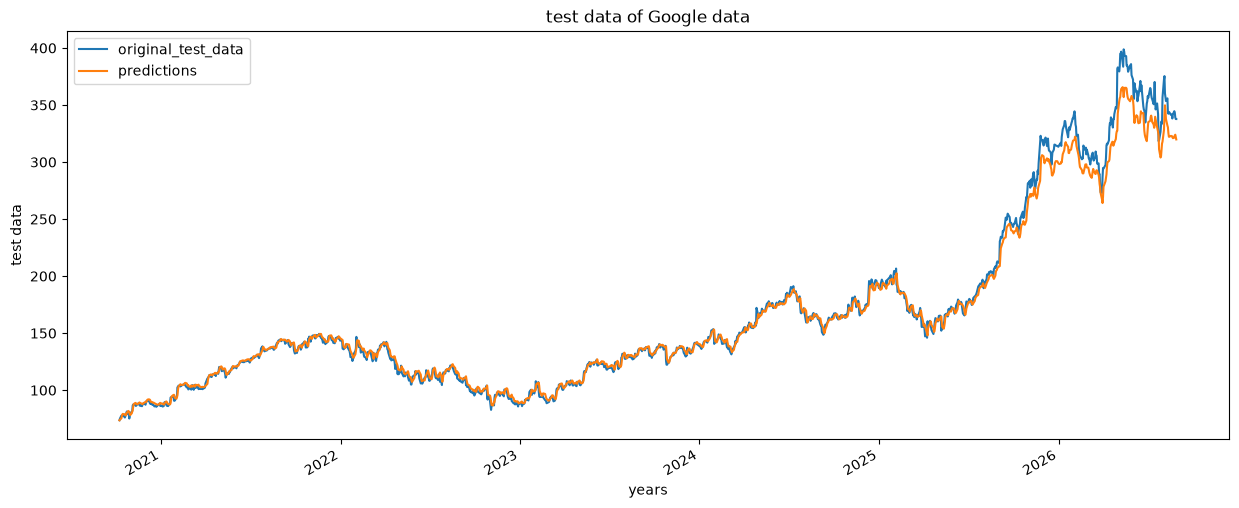

In [178]:
plot_graph((15,6), ploting_data, 'test data')

<Figure size 640x480 with 0 Axes>

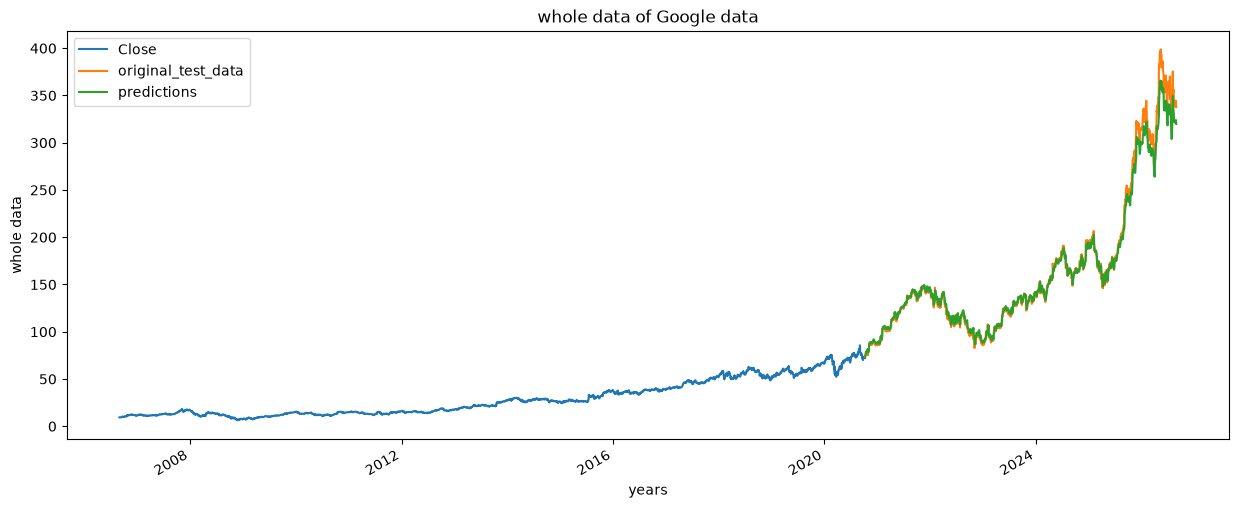

In [179]:
plot_graph((15,6), pd.concat([Adj_close_price[:splitting_len+100],ploting_data], axis=0), 'whole data')

In [180]:
model.save("Latest_stock_price_model.keras")